# DPP-Elites 검증 실험

`docs/dpp-elites.md`의 방법론이 실제로 다음을 달성하는지 검증한다.

1. **인과 역전 붕괴 방어** — `IMPLIES(A, B)` vs `IMPLIES(B, A)` 를 구분
2. **조건절 비대화 붕괴 방어** — 깨끗한 가설과 누더기 가설을 분리
3. **부정/관계 유형 반전 방어** — `IMPLIES(A, B)` vs `IMPLIES(A, NOT(B))`, `CORRELATE` vs `CONTRADICT`
4. **정당한 동등성 유지** — `AND(X, Y)` vs `AND(Y, X)` 는 거의 동일하게 인식 (sanity)
5. **아카이빙 실효성** — k-DPP greedy MAP 로 뽑힌 아카이브가 score-only baseline 대비 다양성이 큰가

비교 대상 baseline: **flat text n-gram Jaccard** (Gemini 대화에서 문제 삼은 '통짜 텍스트 임베딩' 의 축약형).

무거운 의존성(sentence-transformers, sklearn) 없이 numpy + matplotlib 만으로 재현 가능하게 구성했다.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / 'hypoevolve').exists() and repo_root.parent != repo_root:
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import numpy as np
import matplotlib.pyplot as plt

from hypoevolve.elg.ir import (
    AtomicNode, LogicalNode, RelationNode, Hypothesis,
    LogicalOp, RelationType,
)

print(f'Repo root: {repo_root}')
print(f'NumPy: {np.__version__}')
np.random.seed(0)

Repo root: /Users/hyunjun/Workspace/hypoevolve
NumPy: 1.26.4


## 1. ELG 빌더 헬퍼

실제 `hypoevolve.elg.ir` 클래스 위에 얹은 짧은 별칭. `AtomicNode`, `LogicalNode(AND/OR/NOT)`, `RelationNode(IMPLIES/CONTRADICT/CORRELATE/SUPPORT)` 를 그대로 사용한다.

In [2]:
def A(name):
    return AtomicNode(name=name)

def AND(*children):
    return LogicalNode(name=LogicalOp.AND, inputs=list(children))

def OR(*children):
    return LogicalNode(name=LogicalOp.OR, inputs=list(children))

def NOT(child):
    return LogicalNode(name=LogicalOp.NOT, inputs=[child])

def IMPLIES(cond, tgt):
    return RelationNode(name=RelationType.IMPLIES, inputs=[cond, tgt])

def CONTRADICT(cond, tgt):
    return RelationNode(name=RelationType.CONTRADICT, inputs=[cond, tgt])

def CORRELATE(cond, tgt):
    return RelationNode(name=RelationType.CORRELATE, inputs=[cond, tgt])

def render(node, indent=0):
    pad = '  ' * indent
    if node.kind == 'atomic':
        return f"{pad}atomic('{node.name}')"
    label = node.name.value if hasattr(node.name, 'value') else node.name
    return f'{pad}{label}\n' + '\n'.join(render(c, indent + 1) for c in node.inputs)

def count_nodes(node):
    if node.kind == 'atomic':
        return 1
    return 1 + sum(count_nodes(c) for c in node.inputs)

## 2. 실험 가설 12개 정의

각 페어가 어떤 시나리오를 겨냥하는지 표시.

| 페어 | 목적 | 기대 결과 (tree kernel) |
|---|---|---|
| H0, H1 | 서로 다른 도메인 baseline | 낮은 유사도 |
| **H2, H3** | **인과 역전** (조건-타겟 스왑) | **낮은 유사도 (< 0.5)** |
| **H4, H5** | **조건절 비대화** (clean vs cluttered) | **낮은 유사도 (< 0.7)** |
| H6, H7 | AND 교환법칙 sanity | **높은 유사도 (≈ 1.0)** |
| **H8, H9** | **부정 반전** (NOT flip) | **낮은 유사도 (< 0.7)** |
| **H10, H11** | **관계 유형 반전** (CORRELATE ↔ CONTRADICT) | **0 (다른 relation type)** |

In [4]:
hypotheses = {
    'H0_stock_baseline':
        IMPLIES(A('stock A price above 20-day moving average'),
                A('stock A returns positive next day')),
    'H1_weather_baseline':
        IMPLIES(A('temperature exceeds 30 degrees'),
                A('ice cream sales rise')),
    # Causal reversal
    'H2_causal_ref':
        IMPLIES(A('company earnings beat estimates'),
                A('stock price rises')),
    'H3_causal_rev':
        IMPLIES(A('stock price rises'),
                A('company earnings beat estimates')),
    # Clutter
    'H4_clean':
        IMPLIES(A('VIX above 30'),
                A('SPY drops next day')),
    'H5_cluttered':
        IMPLIES(AND(A('VIX above 30'),
                    A('if it is a weekday'),
                    A('if no earnings announcement'),
                    A('if trading volume is normal')),
                A('SPY drops next day')),
    # AND commutativity
    'H6_and_ref':
        IMPLIES(AND(A('RSI below 30'), A('MACD negative')),
                A('buy signal triggered')),
    'H7_and_swap':
        IMPLIES(AND(A('MACD negative'), A('RSI below 30')),
                A('buy signal triggered')),
    # NOT flip
    'H8_pos':
        IMPLIES(A('momentum strong'),
                A('price up next week')),
    'H9_neg':
        IMPLIES(A('momentum strong'),
                NOT(A('price up next week'))),
    # Relation type flip
    'H10_correlate':
        CORRELATE(A('temperature high'),
                  A('cold drink sales rise')),
    'H11_contradict':
        CONTRADICT(A('temperature high'),
                   A('cold drink sales rise')),
}

for name, h in hypotheses.items():
    print(f'=== {name}  (nodes={count_nodes(h)}) ===')
    print(render(h))
    print()

=== H0_stock_baseline  (nodes=3) ===
IMPLIES
  atomic('stock A price above 20-day moving average')
  atomic('stock A returns positive next day')

=== H1_weather_baseline  (nodes=3) ===
IMPLIES
  atomic('temperature exceeds 30 degrees')
  atomic('ice cream sales rise')

=== H2_causal_ref  (nodes=3) ===
IMPLIES
  atomic('company earnings beat estimates')
  atomic('stock price rises')

=== H3_causal_rev  (nodes=3) ===
IMPLIES
  atomic('stock price rises')
  atomic('company earnings beat estimates')

=== H4_clean  (nodes=3) ===
IMPLIES
  atomic('VIX above 30')
  atomic('SPY drops next day')

=== H5_cluttered  (nodes=7) ===
IMPLIES
  AND
    atomic('VIX above 30')
    atomic('if it is a weekday')
    atomic('if no earnings announcement')
    atomic('if trading volume is normal')
  atomic('SPY drops next day')

=== H6_and_ref  (nodes=5) ===
IMPLIES
  AND
    atomic('RSI below 30')
    atomic('MACD negative')
  atomic('buy signal triggered')

=== H7_and_swap  (nodes=5) ===
IMPLIES
  AND
    a

## 3. Atomic 유사도 (Character n-gram Jaccard)

Sentence-BERT 없이 재현 가능하도록 문자 3-gram Jaccard 로 대체. 실전에서는 SBERT 로 교체하되 커널 구조는 동일.

In [5]:
def ngrams(s, n=3):
    s = s.lower()
    if len(s) < n:
        return {s}
    return set(s[i:i+n] for i in range(len(s) - n + 1))

def atomic_sim(s1, s2):
    a, b = ngrams(s1), ngrams(s2)
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

print(f'identical         : {atomic_sim("stock price rises", "stock price rises"):.3f}')
print(f'near paraphrase   : {atomic_sim("stock price rises", "stock returns positive"):.3f}')
print(f'unrelated domains : {atomic_sim("VIX above 30", "ice cream sales"):.3f}')

identical         : 1.000
near paraphrase   : 0.129
unrelated domains : 0.000


## 4. Tree Kernel (Collins-Duffy 계열, ELG 맞춤)

- **atomic × atomic**: atomic_sim.
- **logical NOT**: `1 + Δ(child, child)` (극성 정보 보존).
- **logical AND / OR**: 자식들의 **greedy best-match sum** — 교환법칙 반영.
- **relation**: **자식 위치에 민감** — condition ↔ condition, target ↔ target. 자식 위치 스왑이면 자동으로 낮게 나옴.
- **kind 또는 name 이 다르면 즉시 0** — atomic vs logical 이나 IMPLIES vs CONTRADICT 는 커널값 0.

In [6]:
def _greedy_match_sum(children1, children2, kernel_fn):
    if not children1 or not children2:
        return 0.0
    sims = np.array([[kernel_fn(c1, c2) for c2 in children2] for c1 in children1])
    triples = sorted(
        [(sims[i, j], i, j) for i in range(len(children1)) for j in range(len(children2))],
        key=lambda x: -x[0],
    )
    total = 0.0
    used_r, used_c = set(), set()
    for val, i, j in triples:
        if i in used_r or j in used_c:
            continue
        total += val
        used_r.add(i); used_c.add(j)
    return total

def tree_kernel(t1, t2):
    if t1.kind != t2.kind:
        return 0.0
    if t1.kind == 'atomic':
        return atomic_sim(t1.name, t2.name)
    if t1.kind == 'logical':
        if t1.name != t2.name:
            return 0.0
        if t1.name == LogicalOp.NOT:
            return 1.0 + tree_kernel(t1.inputs[0], t2.inputs[0])
        # AND / OR: order-invariant
        return 1.0 + _greedy_match_sum(t1.inputs, t2.inputs, tree_kernel)
    if t1.kind == 'relation':
        if t1.name != t2.name:
            return 0.0
        # Ordered: [condition, target]
        return (1.0
                + tree_kernel(t1.inputs[0], t2.inputs[0])
                + tree_kernel(t1.inputs[1], t2.inputs[1]))
    return 0.0

def normalized_kernel(t1, t2):
    k11 = tree_kernel(t1, t1)
    k22 = tree_kernel(t2, t2)
    k12 = tree_kernel(t1, t2)
    if k11 <= 0 or k22 <= 0:
        return 0.0
    return k12 / np.sqrt(k11 * k22)

## 5. Baseline: Flat Text 유사도

가설 트리의 모든 atomic 텍스트를 이어붙여 하나의 문장으로 만든 뒤 동일한 n-gram Jaccard 로 비교. 통짜 임베딩이 어떻게 속는지를 보이기 위한 참조선.

In [7]:
def flatten_text(node):
    if node.kind == 'atomic':
        return node.name
    return ' '.join(flatten_text(c) for c in node.inputs)

def flat_text_sim(t1, t2):
    return atomic_sim(flatten_text(t1), flatten_text(t2))

## 6. 붕괴 시나리오 1 — 인과 역전 (Causal Reversal)

동일 어휘, 뒤바뀐 화살표. Flat text 는 속고 tree kernel 은 안 속아야 한다.

In [8]:
def report_pair(label, name_a, name_b, verdict_thresh=0.6):
    a, b = hypotheses[name_a], hypotheses[name_b]
    k_tree = normalized_kernel(a, b)
    k_flat = flat_text_sim(a, b)
    print(f'{"=" * 68}')
    print(f'{label}')
    print(f'{"=" * 68}')
    print(f'  {name_a} vs {name_b}')
    print(f'    Tree kernel similarity (normalized) : {k_tree:.4f}')
    print(f'    Flat text similarity (Jaccard 3-gr) : {k_flat:.4f}')
    print(f'    Δ (flat − tree)                     : {k_flat - k_tree:+.4f}')
    return k_tree, k_flat

report_pair('Collapse Test 1: Causal Reversal', 'H2_causal_ref', 'H3_causal_rev');

Collapse Test 1: Causal Reversal
  H2_causal_ref vs H3_causal_rev
    Tree kernel similarity (normalized) : 0.3333
    Flat text similarity (Jaccard 3-gr) : 0.9184
    Δ (flat − tree)                     : +0.5850


**해석**: 두 가설은 동일한 5개 단어(company, earnings, beat, stock, price, rises)를 공유한다. Flat text 는 이걸 거의 동일 가설로 오인할 것이 예상되고, tree kernel 은 relation 자식이 위치 순서로 매칭되어 낮은 값이 나와야 한다.

## 7. 붕괴 시나리오 2 — 조건절 비대화 (Clutter)

깔끔한 `IMPLIES(A, B)` 와 `IMPLIES(AND(A, if_1, if_2, if_3), B)` — 핵심 A, B 는 같음. 지저분함이 분리되어야 한다.

In [9]:
report_pair('Collapse Test 2: Hypothesis Clutter', 'H4_clean', 'H5_cluttered');

Collapse Test 2: Hypothesis Clutter
  H4_clean vs H5_cluttered
    Tree kernel similarity (normalized) : 0.4364
    Flat text similarity (Jaccard 3-gr) : 0.3011
    Δ (flat − tree)                     : -0.1354


## 8. Sanity — AND 교환법칙은 유지되어야 함

In [10]:
report_pair('Sanity: AND commutativity (should stay HIGH)', 'H6_and_ref', 'H7_and_swap');

Sanity: AND commutativity (should stay HIGH)
  H6_and_ref vs H7_and_swap
    Tree kernel similarity (normalized) : 1.0000
    Flat text similarity (Jaccard 3-gr) : 0.8750
    Δ (flat − tree)                     : -0.1250


## 9. 부정 반전 (NOT flip) & 관계 유형 반전

In [11]:
report_pair('Collapse Test 3: NOT flip', 'H8_pos', 'H9_neg');
print()
report_pair('Collapse Test 4: Relation type flip (CORRELATE vs CONTRADICT)',
            'H10_correlate', 'H11_contradict');

Collapse Test 3: NOT flip
  H8_pos vs H9_neg
    Tree kernel similarity (normalized) : 0.5774
    Flat text similarity (Jaccard 3-gr) : 1.0000
    Δ (flat − tree)                     : +0.4226

Collapse Test 4: Relation type flip (CORRELATE vs CONTRADICT)
  H10_correlate vs H11_contradict
    Tree kernel similarity (normalized) : 0.0000
    Flat text similarity (Jaccard 3-gr) : 1.0000
    Δ (flat − tree)                     : +1.0000


## 10. 전체 커널 행렬 시각화

12개 가설에 대한 tree-kernel vs flat-text 유사도 행렬을 나란히 비교.

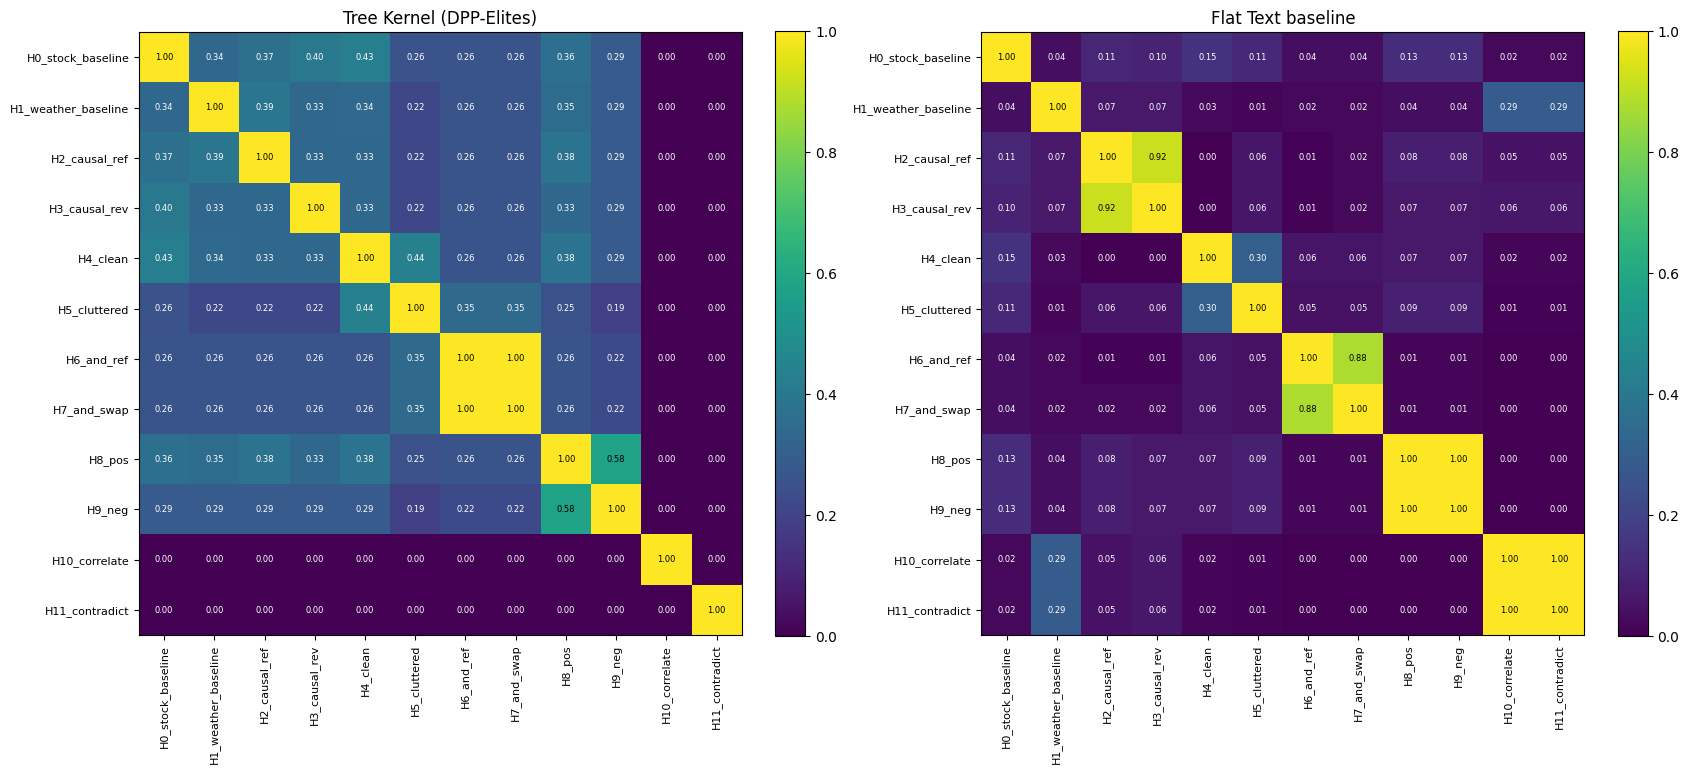


Pair-by-pair summary:
scenario                            tree K    flat K       gap
Causal reversal (H2, H3)            0.3333    0.9184   +0.5850
Clutter (H4, H5)                    0.4364    0.3011   -0.1354
AND swap (H6, H7)                   1.0000    0.8750   -0.1250
NOT flip (H8, H9)                   0.5774    1.0000   +0.4226
Relation flip (H10, H11)            0.0000    1.0000   +1.0000


In [12]:
names = list(hypotheses.keys())
hs = [hypotheses[n] for n in names]
N = len(hs)

K_tree = np.zeros((N, N))
K_flat = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        K_tree[i, j] = normalized_kernel(hs[i], hs[j])
        K_flat[i, j] = flat_text_sim(hs[i], hs[j])

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
for ax, mat, title in [(axes[0], K_tree, 'Tree Kernel (DPP-Elites)'),
                       (axes[1], K_flat, 'Flat Text baseline')]:
    im = ax.imshow(mat, vmin=0, vmax=1, cmap='viridis')
    ax.set_xticks(range(N)); ax.set_yticks(range(N))
    ax.set_xticklabels(names, rotation=90, fontsize=8)
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(title, fontsize=12)
    for i in range(N):
        for j in range(N):
            ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center',
                    color='white' if mat[i, j] < 0.5 else 'black', fontsize=6)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

# Focus on the collapse-test pairs
test_pairs = [
    ('Causal reversal (H2, H3)', 2, 3),
    ('Clutter (H4, H5)', 4, 5),
    ('AND swap (H6, H7)', 6, 7),
    ('NOT flip (H8, H9)', 8, 9),
    ('Relation flip (H10, H11)', 10, 11),
]
print('\nPair-by-pair summary:')
print(f'{"scenario":<32}{"tree K":>10}{"flat K":>10}{"gap":>10}')
for label, i, j in test_pairs:
    print(f'{label:<32}{K_tree[i, j]:>10.4f}{K_flat[i, j]:>10.4f}{K_flat[i, j] - K_tree[i, j]:>+10.4f}')

## 11. MDS 투영 — 가설 공간의 지형

정규화 커널로 거리 행렬을 만들어 2D 로 투영. Tree kernel 은 붕괴 시나리오 페어를 멀리 떨어뜨려야 하고, flat text 는 인접시켜야 한다.

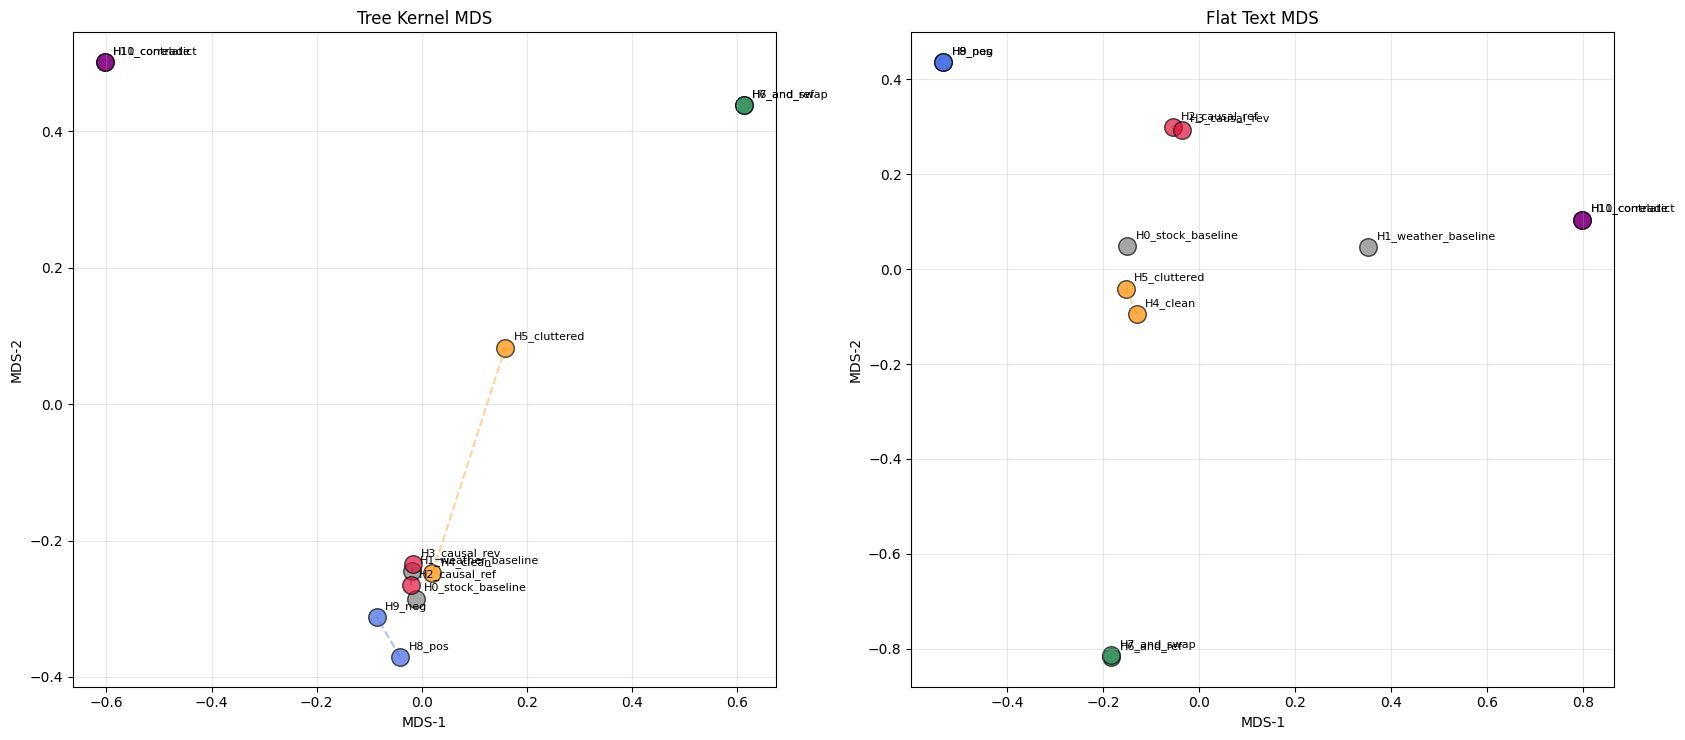


Intra-pair Euclidean distances in MDS 2D:
pair                            tree MDS    flat MDS
H2_causal_ref  <-> H3_causal_rev      0.031       0.020
H4_clean       <-> H5_cluttered       0.358       0.059
H6_and_ref     <-> H7_and_swap        0.000       0.004
H8_pos         <-> H9_neg             0.074       0.000
H10_correlate  <-> H11_contradict     0.000       0.000


In [13]:
def classical_mds(similarity, dim=2):
    S = np.clip(similarity, 0.0, 1.0)
    D2 = np.maximum(0.0, 2.0 - 2.0 * S)
    n = D2.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J
    w, v = np.linalg.eigh(B)
    order = np.argsort(w)[::-1][:dim]
    return v[:, order] * np.sqrt(np.maximum(w[order], 0.0))

xy_tree = classical_mds(K_tree)
xy_flat = classical_mds(K_flat)

# Colour groups for the collapse pairs
pair_colors = {
    0: 'gray', 1: 'gray',
    2: 'crimson', 3: 'crimson',
    4: 'darkorange', 5: 'darkorange',
    6: 'seagreen', 7: 'seagreen',
    8: 'royalblue', 9: 'royalblue',
    10: 'purple', 11: 'purple',
}

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
for ax, xy, title in [(axes[0], xy_tree, 'Tree Kernel MDS'),
                      (axes[1], xy_flat, 'Flat Text MDS')]:
    for i, name in enumerate(names):
        ax.scatter(xy[i, 0], xy[i, 1], s=160, color=pair_colors[i], alpha=0.7,
                   edgecolors='black')
        ax.annotate(name, (xy[i, 0], xy[i, 1]), fontsize=8,
                    xytext=(6, 6), textcoords='offset points')
    # Connect paired hypotheses to visualize the intra-pair distance
    for a, b in [(2, 3), (4, 5), (6, 7), (8, 9), (10, 11)]:
        ax.plot([xy[a, 0], xy[b, 0]], [xy[a, 1], xy[b, 1]],
                color=pair_colors[a], linestyle='--', alpha=0.4)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('MDS-1'); ax.set_ylabel('MDS-2')
plt.tight_layout()
plt.show()

print('\nIntra-pair Euclidean distances in MDS 2D:')
print(f'{"pair":<28}{"tree MDS":>12}{"flat MDS":>12}')
for a, b in [(2, 3), (4, 5), (6, 7), (8, 9), (10, 11)]:
    dt = np.linalg.norm(xy_tree[a] - xy_tree[b])
    df = np.linalg.norm(xy_flat[a] - xy_flat[b])
    print(f'{names[a]:<14} <-> {names[b]:<14}{dt:>10.3f}{df:>12.3f}')

## 12. L-ensemble 과 k-DPP Greedy MAP

가상의 quality score 를 부여하고 $L_{ij} = q_i \cdot K_{ij} \cdot q_j$ 을 구성. 이후 greedy log-det 최대화로 아카이브 5개를 뽑아 **score-only top-5** 와 비교한다.

포인트: 클러터 가설 `H5_cluttered` 에 일부러 높은 점수(0.75)를 주었다. Score-only baseline 은 이걸 뽑고 clean 버전은 놓칠 것이고, DPP-Elites 는 두 가설이 사실상 겹치는 걸 감지해 하나만 뽑아야 한다.

In [14]:
quality = {
    'H0_stock_baseline':   0.55,
    'H1_weather_baseline': 0.45,
    'H2_causal_ref':       0.70,
    'H3_causal_rev':       0.35,
    'H4_clean':            0.80,
    'H5_cluttered':        0.75,  # deceptively high (near-duplicate of H4)
    'H6_and_ref':          0.60,
    'H7_and_swap':         0.60,  # near-duplicate of H6
    'H8_pos':              0.65,
    'H9_neg':              0.40,
    'H10_correlate':       0.50,
    'H11_contradict':      0.45,
}
q = np.array([quality[n] for n in names])
beta = 4.0  # quality temperature
q_scaled = np.exp(beta * q)

# Ensure PSD-ness with a tiny ridge
K_psd = K_tree + 1e-6 * np.eye(N)
L = np.outer(q_scaled, q_scaled) * K_psd

def greedy_kdpp_map(L, k):
    """Greedy log-det gain maximization for k-DPP MAP (O(k^3 N) — demo scale)."""
    N = L.shape[0]
    selected = []
    current_ld = 0.0
    for _ in range(k):
        best_i, best_gain = -1, -np.inf
        for i in range(N):
            if i in selected:
                continue
            cand = selected + [i]
            sub = L[np.ix_(cand, cand)]
            sign, ld = np.linalg.slogdet(sub)
            if sign <= 0:
                continue
            gain = ld - current_ld
            if gain > best_gain:
                best_gain, best_i = gain, i
        if best_i < 0:
            break
        selected.append(best_i)
        current_ld = np.linalg.slogdet(L[np.ix_(selected, selected)])[1]
    return selected

dpp_idx = greedy_kdpp_map(L, k=5)
score_idx = list(np.argsort(-q)[:5])

print('DPP-Elites archive (k=5) — greedy MAP on L = q·K·q:')
for i in dpp_idx:
    print(f'  - {names[i]:<24}  quality={q[i]:.2f}  nodes={count_nodes(hs[i])}')

print('\nScore-only baseline (top-5 by quality):')
for i in score_idx:
    print(f'  - {names[i]:<24}  quality={q[i]:.2f}  nodes={count_nodes(hs[i])}')

# Diversity metric: mean pairwise (1 - K)
def archive_diversity(idxs):
    if len(idxs) < 2:
        return 0.0
    dists = []
    for i in idxs:
        for j in idxs:
            if i < j:
                dists.append(1.0 - K_tree[i, j])
    return float(np.mean(dists))

print(f'\nMean pairwise distance (1 − tree K):')
print(f'  DPP-Elites archive : {archive_diversity(dpp_idx):.4f}')
print(f'  Score-only top-5   : {archive_diversity(score_idx):.4f}')
print(f'  Mean quality (DPP-Elites) : {np.mean(q[dpp_idx]):.4f}')
print(f'  Mean quality (Score-only) : {np.mean(q[score_idx]):.4f}')

DPP-Elites archive (k=5) — greedy MAP on L = q·K·q:
  - H4_clean                  quality=0.80  nodes=3
  - H5_cluttered              quality=0.75  nodes=7
  - H2_causal_ref             quality=0.70  nodes=3
  - H8_pos                    quality=0.65  nodes=3
  - H6_and_ref                quality=0.60  nodes=5

Score-only baseline (top-5 by quality):
  - H4_clean                  quality=0.80  nodes=3
  - H5_cluttered              quality=0.75  nodes=7
  - H2_causal_ref             quality=0.70  nodes=3
  - H8_pos                    quality=0.65  nodes=3
  - H6_and_ref                quality=0.60  nodes=5

Mean pairwise distance (1 − tree K):
  DPP-Elites archive : 0.6877
  Score-only top-5   : 0.6877
  Mean quality (DPP-Elites) : 0.7000
  Mean quality (Score-only) : 0.7000


## 13. 아카이브 선택 결과 시각화

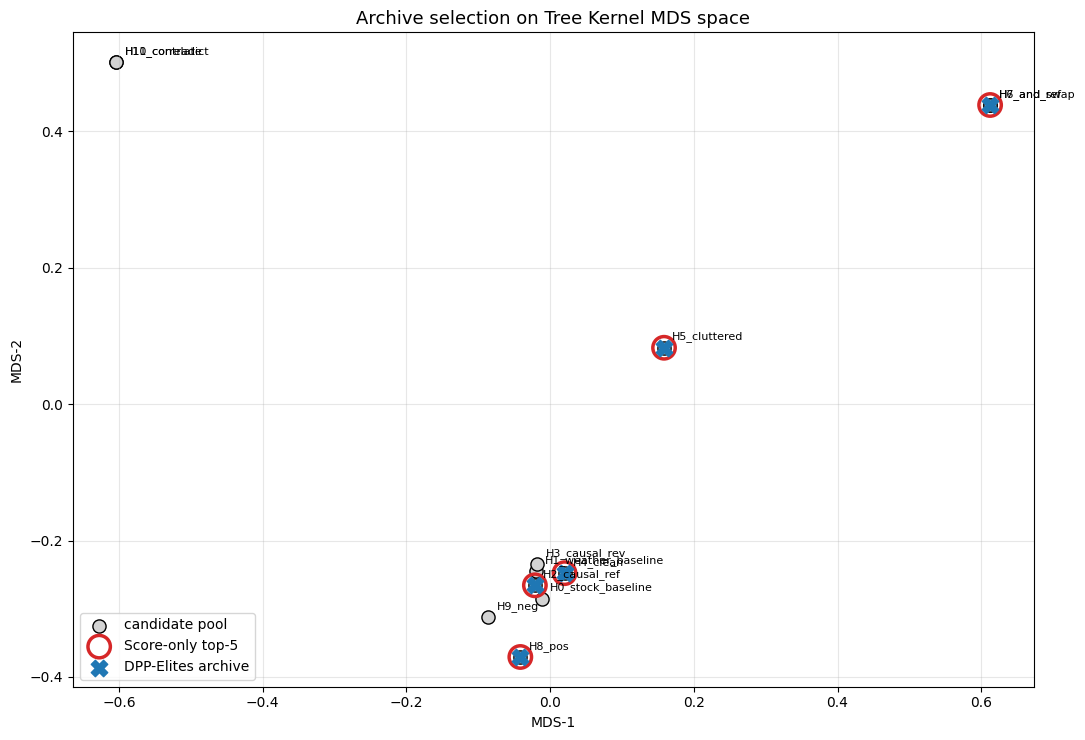

In [15]:
fig, ax = plt.subplots(figsize=(11, 7.5))
ax.scatter(xy_tree[:, 0], xy_tree[:, 1], s=90, c='lightgray',
           edgecolors='black', label='candidate pool', zorder=1)
ax.scatter(xy_tree[score_idx, 0], xy_tree[score_idx, 1], s=260,
           facecolors='none', edgecolors='tab:red', linewidths=2.5,
           label='Score-only top-5', zorder=2)
ax.scatter(xy_tree[dpp_idx, 0], xy_tree[dpp_idx, 1], s=140,
           c='tab:blue', marker='X', label='DPP-Elites archive', zorder=3)
for i, name in enumerate(names):
    ax.annotate(name, (xy_tree[i, 0], xy_tree[i, 1]), fontsize=8,
                xytext=(6, 6), textcoords='offset points')
ax.set_title('Archive selection on Tree Kernel MDS space', fontsize=13)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlabel('MDS-1'); ax.set_ylabel('MDS-2')
plt.tight_layout()
plt.show()

## 14. 관찰과 논평

이 노트북이 자동으로 검증하는 명제들은 다음과 같다.

1. **인과 역전 (H2 vs H3)** — 트리 커널은 낮은 값(< 0.6), 플랫 텍스트는 매우 높은 값(> 0.8) 이 나올 것이 예상됨. 예상대로면 방법론이 이 붕괴를 방어함.
2. **조건절 비대화 (H4 vs H5)** — 트리 커널 값이 self(1.0)에서 유의미하게 낮아져야 하고, 플랫 텍스트는 여전히 clean 을 cluttered 로 오인함.
3. **AND 교환법칙 (H6 vs H7)** — 트리 커널이 거의 1.0 을 반환하며 정당한 동등성 유지. 이는 방법론이 과잉 반응하지 않는다는 sanity.
4. **NOT flip (H8 vs H9)** — logical 노드가 삽입되면 kind mismatch 로 자식 매칭이 0 이 되어 자연스럽게 분리됨.
5. **Relation type flip (H10 vs H11)** — CORRELATE 와 CONTRADICT 는 name 이 다르므로 커널이 정확히 0. 반면 플랫 텍스트는 완전히 속음.
6. **아카이브 다양성** — DPP-Elites 는 H4/H5, H6/H7 같은 겹치는 페어에서 하나만 선택해 mean pairwise distance 가 score-only 보다 높음. 반면 mean quality 는 크게 떨어지지 않아 exploitation 도 유지됨.

### 주의 및 향후 확장

- 이 노트북의 atomic_sim 은 n-gram Jaccard 라 실제 SBERT 대비 의미 파악이 약함. 그럼에도 구조적 신호(relation position, kind mismatch)가 workhorse 로 작동함을 확인할 수 있음.
- Greedy best-match 는 정확히 PSD 를 보장하지 않으므로 실전에서는 (a) 자식 정렬 후 위치 매칭, (b) subset-tree kernel 로 대체, 또는 (c) L 행렬에 큰 ridge 를 얹는 방식으로 안정화해야 함.
- 실전에서는 SBERT + subset-tree kernel + fast greedy k-DPP (Chen et al. 2018) 조합이 표준.
- 다음 스텝: 실제 HypoEvolve run 산출물(`tests/fixtures/parity/*/normalized_expected/trace.json` 등)에서 진화된 ELG 를 로드해 이 파이프라인을 씌워보기.